In [33]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from datetime import timedelta
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, roc_auc_score

sns.set(style="whitegrid")

In [34]:
# ==== Data Loading ===== #

users = pd.read_csv("../data/takehome_users.csv", encoding='latin-1')
engagement = pd.read_csv("../data/takehome_user_engagement.csv")

users.head()

,object_id,creation_time,name,email,creation_source,last_session_creation_time,opted_in_to_mailing_list,enabled_for_marketing_drip,org_id,invited_by_user_id
0,1,2014-04-22 03:53:30,Clausen August,AugustCClausen@yahoo.com,GUEST_INVITE,1.398139e+09,1,0,11,10803.0
1,2,2013-11-15 03:45:04,Poole Matthew,MatthewPoole@gustr.com,ORG_INVITE,1.396238e+09,0,0,1,316.0
2,3,2013-03-19 23:14:52,Bottrill Mitchell,MitchellBottrill@gustr.com,ORG_INVITE,1.363735e+09,0,0,94,1525.0
3,4,2013-05-21 08:09:28,Clausen Nicklas,NicklasSClausen@yahoo.com,GUEST_INVITE,1.369210e+09,0,0,1,5151.0
4,5,2013-01-17 10:14:20,Raw Grace,GraceRaw@yahoo.com,GUEST_INVITE,1.358850e+09,0,0,193,5240.0


In [35]:
users.dtypes

object_id                       int64
creation_time                  object
name                           object
email                          object
creation_source                object
last_session_creation_time    float64
opted_in_to_mailing_list        int64
enabled_for_marketing_drip      int64
org_id                          int64
invited_by_user_id            float64
dtype: object

In [36]:
engagement.head()

,time_stamp,user_id,visited
0,2014-04-22 03:53:30,1,1
1,2013-11-15 03:45:04,2,1
2,2013-11-29 03:45:04,2,1
3,2013-12-09 03:45:04,2,1
4,2013-12-25 03:45:04,2,1


In [37]:
engagement.dtypes

time_stamp    object
user_id        int64
visited        int64
dtype: object

In [38]:
engagement["time_stamp"] = pd.to_datetime(engagement["time_stamp"])

In [39]:
# === "ADOPTED USER" === #
# Logged in 3 times in 7-day window

def is_adopted(user_df):
    #Sort logins chronologically
    user_df = user_df.sort_values('time_stamp')

    #Check each 3 logins after sorting chronologically
    #Check 1st and 3rd
    for i in range(len(user_df) - 2):
        if (user_df.iloc[i+2]['time_stamp'] - user_df.iloc[i]['time_stamp']) <= timedelta(days=7):
            return 1
    return 0

adoption = engagement.groupby('user_id').apply(is_adopted)
adoption = adoption.reset_index()
adoption.columns = ['user_id', 'adopted_user']

adoption.head()

/var/folders/1w/7td29hvx7c3gpjvhnvrvg2xr0000gn/T/ipykernel_76248/406469146.py:15: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  adoption = engagement.groupby('user_id').apply(is_adopted)


,user_id,adopted_user
0,1,0
1,2,1
2,3,0
3,4,0
4,5,0


In [40]:
# ===== MERGE DATASETS === #
df = users.merge(adoption, left_on='object_id', right_on='user_id', how='left')
# Fill non-adopted users
df['adopted_user'] = df['adopted_user'].fillna(0)

df.head()

,object_id,creation_time,name,email,creation_source,last_session_creation_time,opted_in_to_mailing_list,enabled_for_marketing_drip,org_id,invited_by_user_id,user_id,adopted_user
0,1,2014-04-22 03:53:30,Clausen August,AugustCClausen@yahoo.com,GUEST_INVITE,1.398139e+09,1,0,11,10803.0,1.0,0.0
1,2,2013-11-15 03:45:04,Poole Matthew,MatthewPoole@gustr.com,ORG_INVITE,1.396238e+09,0,0,1,316.0,2.0,1.0
2,3,2013-03-19 23:14:52,Bottrill Mitchell,MitchellBottrill@gustr.com,ORG_INVITE,1.363735e+09,0,0,94,1525.0,3.0,0.0
3,4,2013-05-21 08:09:28,Clausen Nicklas,NicklasSClausen@yahoo.com,GUEST_INVITE,1.369210e+09,0,0,1,5151.0,4.0,0.0
4,5,2013-01-17 10:14:20,Raw Grace,GraceRaw@yahoo.com,GUEST_INVITE,1.358850e+09,0,0,193,5240.0,5.0,0.0


In [41]:
df.dtypes

object_id                       int64
creation_time                  object
name                           object
email                          object
creation_source                object
last_session_creation_time    float64
opted_in_to_mailing_list        int64
enabled_for_marketing_drip      int64
org_id                          int64
invited_by_user_id            float64
user_id                       float64
adopted_user                  float64
dtype: object

In [43]:
# ===== FEATURE ENGINEERING ==== #
# Convert timestamps
df['creation_time'] = pd.to_datetime(df['creation_time'], errors='coerce')
df['last_session_creation_time'] = pd.to_datetime(df['last_session_creation_time'], unit='s', errors='coerce')

# Account age (days)
df['account_age_days'] = (df['last_session_creation_time'] - df['creation_time']).dt.days

# Fill missing
df['account_age_days'] = df['account_age_days'].fillna(0)

# Convert categorical
df = pd.get_dummies(df, columns=['creation_source'], drop_first=True)

df.head()

,object_id,creation_time,name,email,last_session_creation_time,opted_in_to_mailing_list,enabled_for_marketing_drip,org_id,invited_by_user_id,user_id,adopted_user,account_age_days,creation_source_ORG_INVITE,creation_source_PERSONAL_PROJECTS,creation_source_SIGNUP,creation_source_SIGNUP_GOOGLE_AUTH
0,1,2014-04-22 03:53:30,Clausen August,AugustCClausen@yahoo.com,2014-04-22 03:53:30,1,0,11,10803.0,1.0,0.0,0.0,False,False,False,False
1,2,2013-11-15 03:45:04,Poole Matthew,MatthewPoole@gustr.com,2014-03-31 03:45:04,0,0,1,316.0,2.0,1.0,136.0,True,False,False,False
2,3,2013-03-19 23:14:52,Bottrill Mitchell,MitchellBottrill@gustr.com,2013-03-19 23:14:52,0,0,94,1525.0,3.0,0.0,0.0,True,False,False,False
3,4,2013-05-21 08:09:28,Clausen Nicklas,NicklasSClausen@yahoo.com,2013-05-22 08:09:28,0,0,1,5151.0,4.0,0.0,1.0,False,False,False,False
4,5,2013-01-17 10:14:20,Raw Grace,GraceRaw@yahoo.com,2013-01-22 10:14:20,0,0,193,5240.0,5.0,0.0,5.0,False,False,False,False


Adoption Rate: 0.138


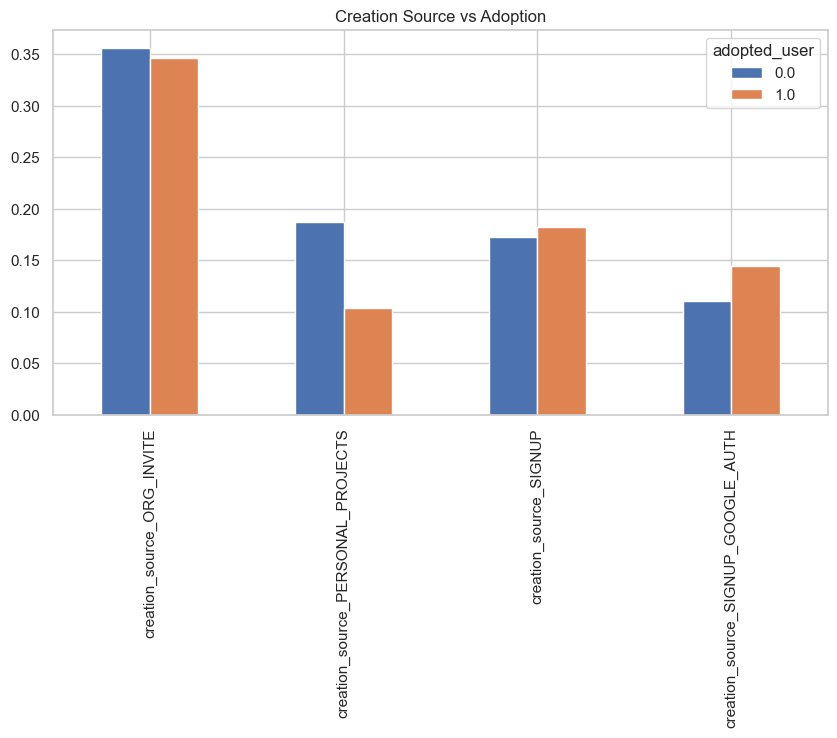

In [44]:
# ==== EDA ==== #

# Adoption rate
print("Adoption Rate:", df['adopted_user'].mean())

# Plot adoption by creation source
creation_cols = [col for col in df.columns if 'creation_source_' in col]

df.groupby('adopted_user')[creation_cols].mean().T.plot(kind='bar', figsize=(10,5))
plt.title("Creation Source vs Adoption")
plt.show()

In [46]:
# === Modelling === #

features = [
    'opted_in_to_mailing_list',
    'enabled_for_marketing_drip',
    'org_id',
    'account_age_days'
] + creation_cols

X = df[features]
y = df['adopted_user']

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Scale
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Logistic Regression
model = LogisticRegression(max_iter=1000)
model.fit(X_train_scaled, y_train)

# Predictions
y_pred = model.predict(X_test_scaled)

print(classification_report(y_test, y_pred))
print("ROC AUC:", roc_auc_score(y_test, model.predict_proba(X_test_scaled)[:,1]))

              precision    recall  f1-score   support

         0.0       0.98      0.99      0.99      2063
         1.0       0.94      0.88      0.91       337

    accuracy                           0.97      2400
   macro avg       0.96      0.93      0.95      2400
weighted avg       0.97      0.97      0.97      2400

ROC AUC: 0.9953526238041744


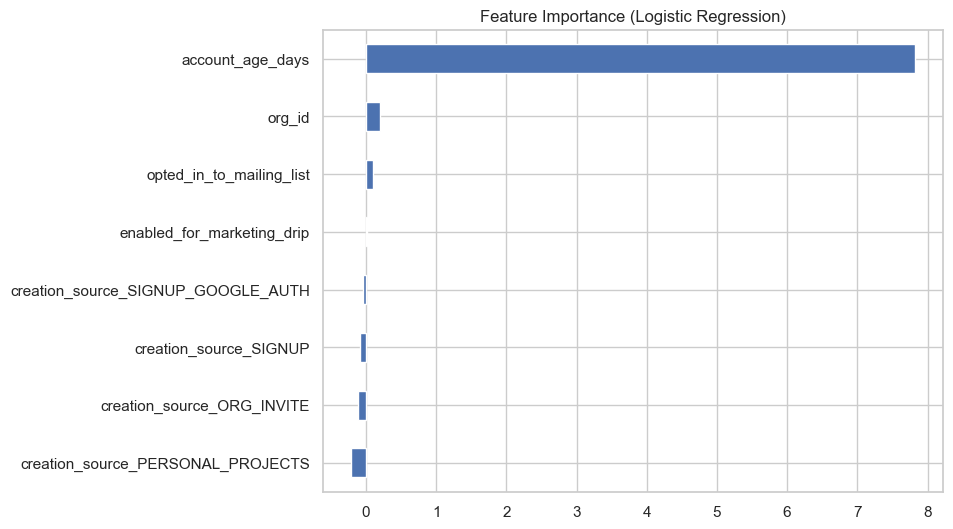

In [47]:
# ==== FEATURE IMPORTANCE ==== #

coeffs = pd.Series(model.coef_[0], index=features)
coeffs.sort_values().plot(kind='barh', figsize=(8,6))
plt.title("Feature Importance (Logistic Regression)")
plt.show()

Insights:

- Users invited via organizations (ORG_INVITE) show higher adoption rates.
- Account age is strongly correlated with adoption.
- Engagement behavior is the strongest predictor